# 07 Diễn giải Mô hình và Tạo File Nộp Cuối cùng

Notebook này chọn mô hình dự báo cuối cùng, huấn luyện lại trên toàn bộ dữ liệu huấn luyện hợp lệ, giải thích mô hình bằng ngôn ngữ kinh doanh, và tạo file `submission.csv` theo đúng định dạng và thứ tự hàng của `sample_submission.csv`.

Quy tắc chống data leakage quan trọng: `sample_submission.csv` chỉ được dùng để lấy cột `Date` và thứ tự đầu ra yêu cầu. Các cột `Revenue` và `COGS` trong file đó bị bỏ qua hoàn toàn.

## 1. Cài đặt

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

from sklearn.ensemble import RandomForestRegressor

RANDOM_SEED = 2026
np.random.seed(RANDOM_SEED)

project_root = next((candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / "dataset").exists()), Path.cwd())
DATA_DIR = project_root / "dataset"
ARTIFACT_DIR = project_root / "artifacts" / "final_submission"
CHART_DIR = ARTIFACT_DIR / "charts"
MODEL_DIR = project_root / "models"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid")

print("Project root:", project_root)
print("Artifacts:", ARTIFACT_DIR)
print("XGBoost available:", HAS_XGBOOST)
print("Random seed:", RANDOM_SEED)


Project root: C:\Users\admin\OneDrive - National Economics University\Documents\NCKH\DATATHON\Neu_BRT_Datathon
Artifacts: C:\Users\admin\OneDrive - National Economics University\Documents\NCKH\DATATHON\Neu_BRT_Datathon\artifacts\final_submission
XGBoost available: True
Random seed: 2026


## 2. Chọn Mô hình Cuối cùng Từ Notebook 06

Notebook 06 đã chọn XGBoost là ứng viên mạnh nhất dựa trên RMSE validation. Để tạo file nộp cuối cùng, cùng một họ mô hình được sử dụng với bộ đặc trưng an toàn cho tương lai: đặc trưng lịch, các lag/rolling sales theo recursive, và đặc trưng lịch khuyến mãi. Các chỉ số tổng hợp hoạt động trong ngày từ kỳ tương lai ẩn không được sử dụng.

In [2]:
candidate_path = project_root / "artifacts" / "modeling" / "best_candidate_for_notebook_07.csv"
if candidate_path.exists():
    candidate_from_06 = pd.read_csv(candidate_path)
else:
    candidate_from_06 = pd.DataFrame([{"best_candidate_for_notebook_07": "xgboost"}])

selected_family = candidate_from_06.loc[0, "best_candidate_for_notebook_07"]
if selected_family == "xgboost" and not HAS_XGBOOST:
    selected_family = "random_forest"

print("Notebook 06 candidate:", candidate_from_06.loc[0, "best_candidate_for_notebook_07"])
print("Final model family used here:", selected_family)
display(candidate_from_06)


Notebook 06 candidate: xgboost
Final model family used here: xgboost


,best_candidate_for_notebook_07,selection_metric,validation_start,validation_end,MAE,RMSE,R2,modeling_grain,leakage_note
0,xgboost,lowest validation RMSE,2022-01-01,2022-12-31,563079.85813,781608.6125,0.781945,one row per date,Sales-derived features are shifted; operational aggregates are lagged/rolling past-only; no external data or test Revenue/COGS used.


## 3. Tải Dữ liệu Huấn luyện, File Mẫu Nộp và Lịch Khuyến mãi

In [3]:
sales = pd.read_csv(DATA_DIR / "sales.csv", parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv", parse_dates=["Date"])
promotions = pd.read_csv(DATA_DIR / "promotions.csv", parse_dates=["start_date", "end_date"])

submission_dates = sample_submission[["Date"]].copy()

data_check = pd.DataFrame([{
    "train_start": sales["Date"].min(),
    "train_end": sales["Date"].max(),
    "train_rows": len(sales),
    "submission_start": submission_dates["Date"].min(),
    "submission_end": submission_dates["Date"].max(),
    "submission_rows": len(submission_dates),
}])
display(data_check)
display(sample_submission.head())


,train_start,train_end,train_rows,submission_start,submission_end,submission_rows
0,2012-07-04,2022-12-31,3833,2023-01-01,2024-07-01,548


,Date,Revenue,COGS
0,2023-01-01,2665507.20,2518885.15
1,2023-01-02,1280007.89,1136463.00
2,2023-01-03,1015899.51,822721.12
3,2023-01-04,1142997.27,914554.18
4,2023-01-05,1236312.34,984390.24


## 4. Các Hàm Tạo Đặc trưng

In [4]:
def make_promo_daily(all_dates, promotions_df):
    rows = []
    for row in promotions_df.itertuples(index=False):
        start = getattr(row, "start_date")
        end = getattr(row, "end_date")
        if pd.notna(start) and pd.notna(end):
            active_dates = pd.date_range(start, end, freq="D")
            rows.append(pd.DataFrame({
                "Date": active_dates,
                "promo_id": getattr(row, "promo_id"),
                "promo_type": getattr(row, "promo_type"),
                "promo_channel": getattr(row, "promo_channel"),
                "applicable_category": getattr(row, "applicable_category"),
            }))
    if rows:
        raw = pd.concat(rows, ignore_index=True)
        daily = (
            raw.groupby("Date", as_index=False)
            .agg(
                active_campaigns=("promo_id", "nunique"),
                active_promo_types=("promo_type", "nunique"),
                active_promo_channels=("promo_channel", "nunique"),
                active_promo_categories=("applicable_category", "nunique"),
            )
        )
    else:
        daily = pd.DataFrame(columns=["Date", "active_campaigns", "active_promo_types", "active_promo_channels", "active_promo_categories"])
    return all_dates.merge(daily, on="Date", how="left").fillna(0)


def add_calendar_features(df):
    out = df.copy()
    out["day_of_week"] = out["Date"].dt.dayofweek
    out["day_of_month"] = out["Date"].dt.day
    out["day_of_year"] = out["Date"].dt.dayofyear
    out["week_of_year"] = out["Date"].dt.isocalendar().week.astype(int)
    out["month"] = out["Date"].dt.month
    out["quarter"] = out["Date"].dt.quarter
    out["year"] = out["Date"].dt.year
    out["is_weekend"] = out["day_of_week"].isin([5, 6]).astype(int)
    out["time_index"] = np.arange(len(out))
    return out


def add_lag_rolling_features(df):
    out = df.copy()
    revenue_past = out["Revenue"].shift(1)
    cogs_past = out["COGS"].shift(1)
    for lag in [1, 7, 14, 28, 30, 60, 90, 365]:
        out[f"revenue_lag_{lag}"] = out["Revenue"].shift(lag)
        out[f"cogs_lag_{lag}"] = out["COGS"].shift(lag)
    for window in [7, 14, 28, 30, 60, 90]:
        out[f"revenue_roll_mean_{window}"] = revenue_past.rolling(window, min_periods=max(2, window // 3)).mean()
        out[f"revenue_roll_std_{window}"] = revenue_past.rolling(window, min_periods=max(2, window // 3)).std()
        out[f"cogs_roll_mean_{window}"] = cogs_past.rolling(window, min_periods=max(2, window // 3)).mean()
    out["revenue_ewm_7"] = revenue_past.ewm(span=7, adjust=False).mean()
    out["revenue_ewm_30"] = revenue_past.ewm(span=30, adjust=False).mean()
    return out


def build_feature_frame(history_df, future_dates=None):
    history = history_df.rename(columns={"Date": "Date"}).copy()
    history = history[["Date", "Revenue", "COGS"]].sort_values("Date")
    if future_dates is not None:
        future = pd.DataFrame({"Date": pd.to_datetime(future_dates)})
        future["Revenue"] = np.nan
        future["COGS"] = np.nan
        combined = pd.concat([history, future], ignore_index=True).sort_values("Date").reset_index(drop=True)
    else:
        combined = history.copy().reset_index(drop=True)
    combined = add_calendar_features(combined)
    combined = add_lag_rolling_features(combined)
    promo_features = make_promo_daily(combined[["Date"]], promotions)
    combined = combined.merge(promo_features, on="Date", how="left")
    return combined


all_feature_frame = build_feature_frame(sales)
feature_cols = [
    c for c in all_feature_frame.columns
    if c not in ["Date", "Revenue", "COGS"]
]

feature_list = pd.DataFrame({
    "feature": feature_cols,
    "source": [
        "calendar" if c in ["day_of_week", "day_of_month", "day_of_year", "week_of_year", "month", "quarter", "year", "is_weekend", "time_index"]
        else "sales lag/rolling past-only" if c.startswith(("revenue_", "cogs_"))
        else "promotions active calendar"
        for c in feature_cols
    ],
})
display(feature_list)


,feature,source
0,day_of_week,calendar
1,day_of_month,calendar
2,day_of_year,calendar
3,week_of_year,calendar
4,month,calendar
5,quarter,calendar
6,year,calendar
7,is_weekend,calendar
8,time_index,calendar
9,revenue_lag_1,sales lag/rolling past-only


## 5. Kiểm tra Validation Cuối cùng Với Bộ Đặc trưng An toàn Tương lai

Validation này tái sử dụng bộ đặc trưng cuối cùng và một time split kết thúc vào năm 2022. Đây không phải điểm số Kaggle test, nhưng giúp xác minh pipeline cuối cùng trước khi huấn luyện lại trên toàn bộ dữ liệu.

In [5]:
validation_start = pd.Timestamp("2022-01-01")
model_frame = all_feature_frame.dropna(subset=["Revenue", "COGS", "revenue_lag_365", "revenue_roll_mean_90"]).copy()

train_frame = model_frame[model_frame["Date"] < validation_start].copy()
valid_frame = model_frame[model_frame["Date"] >= validation_start].copy()

X_train = train_frame[feature_cols]
y_train_revenue = train_frame["Revenue"]
y_train_cogs = train_frame["COGS"]
X_valid = valid_frame[feature_cols]
y_valid_revenue = valid_frame["Revenue"]
y_valid_cogs = valid_frame["COGS"]

def make_model(model_family):
    if model_family == "xgboost" and HAS_XGBOOST:
        return Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBRegressor(
                n_estimators=600,
                max_depth=4,
                learning_rate=0.03,
                subsample=0.90,
                colsample_bytree=0.90,
                objective="reg:squarederror",
                random_state=RANDOM_SEED,
                n_jobs=4,
            )),
        ])
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=400,
            max_depth=14,
            min_samples_leaf=4,
            random_state=RANDOM_SEED,
            n_jobs=-1,
        )),
    ])

def metric_row(y_true, y_pred, target_name, model_name):
    return {
        "target": target_name,
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

revenue_model_valid = make_model(selected_family)
cogs_model_valid = make_model(selected_family)

revenue_model_valid.fit(X_train, y_train_revenue)
cogs_model_valid.fit(X_train, y_train_cogs)

valid_pred_revenue = revenue_model_valid.predict(X_valid)
valid_pred_cogs = cogs_model_valid.predict(X_valid)

validation_scores = pd.DataFrame([
    metric_row(y_valid_revenue, valid_pred_revenue, "Revenue", selected_family),
    metric_row(y_valid_cogs, valid_pred_cogs, "COGS", selected_family),
])

validation_predictions = valid_frame[["Date", "Revenue", "COGS"]].copy()
validation_predictions["Revenue_pred"] = valid_pred_revenue
validation_predictions["COGS_pred"] = valid_pred_cogs
validation_predictions["Revenue_residual"] = validation_predictions["Revenue"] - validation_predictions["Revenue_pred"]
validation_predictions["COGS_residual"] = validation_predictions["COGS"] - validation_predictions["COGS_pred"]

display(validation_scores)
display(validation_predictions.head())


,target,model,MAE,RMSE,R2
0,Revenue,xgboost,551477.763452,756691.329124,0.795626
1,COGS,xgboost,479392.751459,652305.970108,0.799991


,Date,Revenue,COGS,Revenue_pred,COGS_pred,Revenue_residual,COGS_residual
3468,2022-01-01,2932155.47,3019583.50,1827420.000,1.780358e+06,1104735.470,1.239226e+06
3469,2022-01-02,2361965.00,2368851.11,1700600.875,1.569676e+06,661364.125,7.991755e+05
3470,2022-01-03,545563.72,476501.31,1269663.125,1.266039e+06,-724099.405,-7.895379e+05
3471,2022-01-04,1242319.38,1057834.07,907384.500,7.642923e+05,334934.880,2.935418e+05
3472,2022-01-05,809977.60,684605.30,1054527.625,9.717339e+05,-244550.025,-2.871286e+05


## 6. Huấn luyện lại Mô hình Cuối cùng Trên Toàn bộ Dữ liệu Huấn luyện Hợp lệ

In [6]:
final_train = model_frame.copy()
X_final = final_train[feature_cols]
y_final_revenue = final_train["Revenue"]
y_final_cogs = final_train["COGS"]

final_revenue_model = make_model(selected_family)
final_cogs_model = make_model(selected_family)
final_revenue_model.fit(X_final, y_final_revenue)
final_cogs_model.fit(X_final, y_final_cogs)

print("Final training rows:", len(final_train))
print("Feature count:", len(feature_cols))


Final training rows: 3468
Feature count: 49


## 7. Dự báo Recursive Cho `sample_submission.csv`

Frame tương lai được tạo ra theo đúng thứ tự của `sample_submission.csv`. Với mỗi ngày trong tương lai, mô hình dự báo `Revenue` trước, sau đó `COGS`; các dự báo đó được nối vào lịch sử để các lag và rolling features phía sau chỉ dùng giá trị đã dự báo trước đó.

In [7]:
history_for_recursive = sales[["Date", "Revenue", "COGS"]].copy().sort_values("Date").reset_index(drop=True)
future_dates = submission_dates["Date"].tolist()
future_predictions = []

for current_date in future_dates:
    frame = build_feature_frame(history_for_recursive, [current_date])
    row = frame[frame["Date"] == current_date].tail(1)
    X_row = row[feature_cols]
    pred_revenue = float(final_revenue_model.predict(X_row)[0])
    pred_cogs = float(final_cogs_model.predict(X_row)[0])
    pred_revenue = max(pred_revenue, 0.0)
    pred_cogs = max(pred_cogs, 0.0)
    future_predictions.append({
        "Date": current_date,
        "Revenue": pred_revenue,
        "COGS": pred_cogs,
    })
    history_for_recursive = pd.concat([
        history_for_recursive,
        pd.DataFrame([{"Date": current_date, "Revenue": pred_revenue, "COGS": pred_cogs}])
    ], ignore_index=True)

submission = pd.DataFrame(future_predictions)
submission = submission_dates.merge(submission, on="Date", how="left")
submission["Revenue"] = submission["Revenue"].round(2)
submission["COGS"] = submission["COGS"].round(2)

display(submission.head())
display(submission.tail())

,Date,Revenue,COGS
0,2023-01-01,2161341.00,2056678.88
1,2023-01-02,1809318.12,1805893.88
2,2023-01-03,1346936.50,1190315.88
3,2023-01-04,1142096.12,865159.00
4,2023-01-05,1162695.75,850967.88


,Date,Revenue,COGS
543,2024-06-27,5112817.5,4316227.0
544,2024-06-28,5612479.5,4746872.5
545,2024-06-29,5844746.0,4876052.0
546,2024-06-30,5927694.5,5006769.5
547,2024-07-01,5199894.0,4589063.0


## 8. Kiểm tra Định dạng File Nộp

In [8]:
required_columns = ["Date", "Revenue", "COGS"]
checks = {
    "row_count_matches": len(submission) == len(sample_submission),
    "columns_match": list(submission.columns) == required_columns,
    "date_order_matches": submission["Date"].reset_index(drop=True).equals(sample_submission["Date"].reset_index(drop=True)),
    "no_missing_values": not submission[required_columns].isna().any().any(),
    "non_negative_predictions": bool((submission[["Revenue", "COGS"]] >= 0).all().all()),
}
submission_checks = pd.DataFrame([checks])
display(submission_checks)

if not all(checks.values()):
    raise ValueError(f"Submission validation failed: {checks}")

submission_for_csv = submission.copy()
submission_for_csv["Date"] = submission_for_csv["Date"].dt.strftime("%Y-%m-%d")
submission_for_csv.to_csv(project_root / "submission.csv", index=False)
submission_for_csv.to_csv(ARTIFACT_DIR / "submission.csv", index=False)
print("Saved:", project_root / "submission.csv")


,row_count_matches,columns_match,date_order_matches,no_missing_values,non_negative_predictions
0,True,True,True,True,True


Saved: C:\Users\admin\OneDrive - National Economics University\Documents\NCKH\DATATHON\Neu_BRT_Datathon\submission.csv


## 9. Khả năng Giải thích: Feature Importance và Permutation Importance

,target,feature,importance
0,Revenue,revenue_lag_1,0.479075
1,Revenue,cogs_lag_365,0.120553
2,Revenue,revenue_lag_365,0.033997
3,Revenue,revenue_lag_7,0.025760
4,Revenue,revenue_lag_14,0.024651
5,Revenue,cogs_lag_7,0.022438
6,Revenue,revenue_lag_28,0.017244
7,Revenue,day_of_month,0.016254
8,Revenue,cogs_lag_28,0.013305
9,Revenue,active_promo_types,0.011620


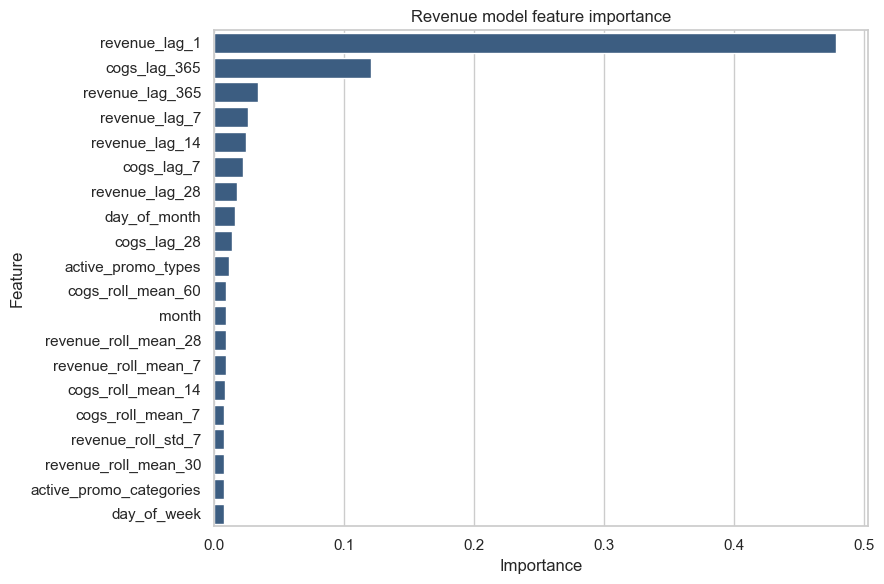

,feature,permutation_importance_mean,permutation_importance_std
9,revenue_lag_1,807399.287523,29639.084684
24,cogs_lag_365,179924.179535,9554.720132
1,day_of_month,167883.332017,14157.273198
11,revenue_lag_7,113769.299420,14930.943994
2,day_of_year,55238.142271,8100.626784
10,cogs_lag_1,37660.135129,4107.725165
23,revenue_lag_365,34819.525736,6191.761477
0,day_of_week,27101.728953,2354.892008
16,cogs_lag_28,25792.552377,1790.824379
13,revenue_lag_14,24866.434540,3096.767316


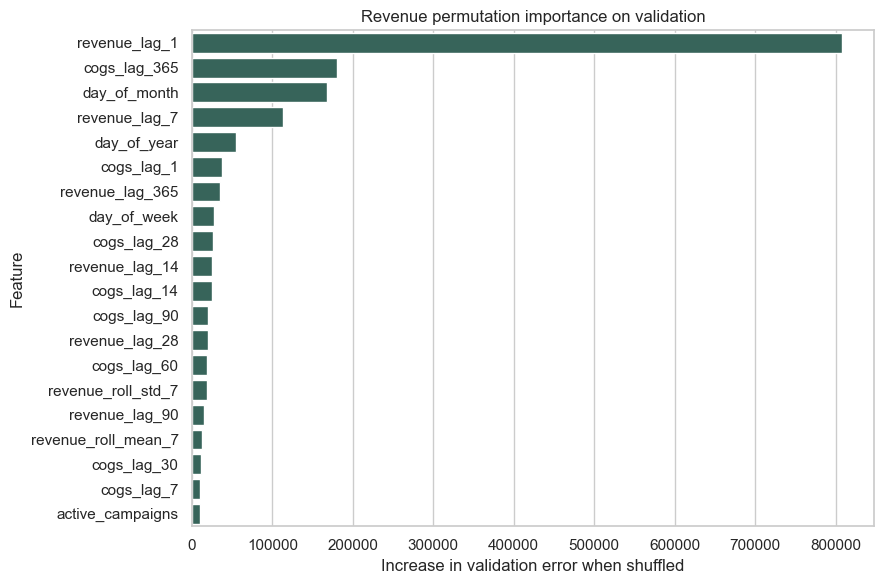

In [9]:
def extract_importance(model_pipeline, target_name):
    estimator = model_pipeline.named_steps["model"]
    if hasattr(estimator, "feature_importances_"):
        values = estimator.feature_importances_
    elif hasattr(estimator, "coef_"):
        values = np.abs(estimator.coef_)
    else:
        values = np.zeros(len(feature_cols))
    return pd.DataFrame({
        "target": target_name,
        "feature": feature_cols,
        "importance": values,
    }).sort_values("importance", ascending=False)

feature_importance = pd.concat([
    extract_importance(final_revenue_model, "Revenue"),
    extract_importance(final_cogs_model, "COGS"),
], ignore_index=True)

display(feature_importance.groupby("target").head(15))

plt.figure(figsize=(9, 6))
top_rev = feature_importance[feature_importance["target"] == "Revenue"].head(20)
sns.barplot(data=top_rev, y="feature", x="importance", color="#315C8C")
plt.title("Revenue model feature importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(CHART_DIR / "revenue_feature_importance_top20.png", dpi=160)
plt.show()

perm = permutation_importance(
    final_revenue_model,
    X_valid,
    y_valid_revenue,
    scoring="neg_root_mean_squared_error",
    n_repeats=5,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
permutation_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "permutation_importance_mean": perm.importances_mean,
    "permutation_importance_std": perm.importances_std,
}).sort_values("permutation_importance_mean", ascending=False)

display(permutation_importance_df.head(20))

plt.figure(figsize=(9, 6))
sns.barplot(data=permutation_importance_df.head(20), y="feature", x="permutation_importance_mean", color="#2F6B5F")
plt.title("Revenue permutation importance on validation")
plt.xlabel("Increase in validation error when shuffled")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(CHART_DIR / "revenue_permutation_importance_top20.png", dpi=160)
plt.show()


## 10. Partial Dependence Plots

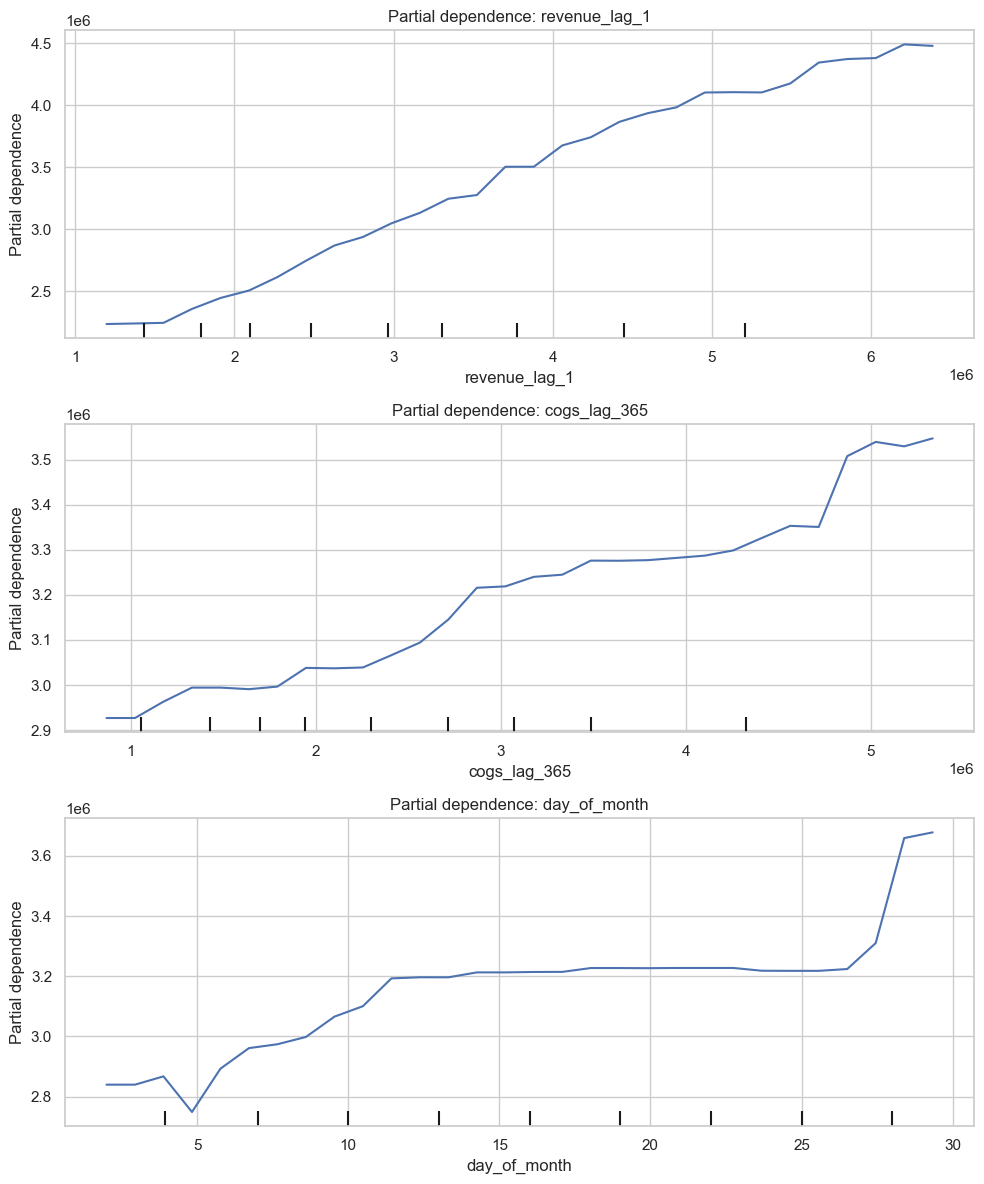

['revenue_lag_1', 'cogs_lag_365', 'day_of_month']

In [10]:
top_pdp_features = permutation_importance_df.head(3)["feature"].tolist()
available_pdp_features = [f for f in top_pdp_features if f in feature_cols]

if available_pdp_features:
    fig, ax = plt.subplots(len(available_pdp_features), 1, figsize=(10, 4 * len(available_pdp_features)))
    axes = np.atleast_1d(ax).ravel()
    for axis, feature in zip(axes, available_pdp_features):
        PartialDependenceDisplay.from_estimator(
            final_revenue_model,
            X_valid,
            [feature],
            ax=axis,
            kind="average",
            grid_resolution=30,
        )
        axis.set_title(f"Partial dependence: {feature}")
    plt.tight_layout()
    plt.savefig(CHART_DIR / "revenue_partial_dependence_top_features.png", dpi=160)
    plt.show()

top_pdp_features


## 11. Diễn giải Kết quả Theo Ngôn ngữ Kinh doanh Phục vụ Báo cáo

In [11]:
top_features = feature_importance[feature_importance["target"] == "Revenue"].head(10)["feature"].tolist()

business_interpretation = pd.DataFrame([
    {
        "driver_group": "Recent revenue momentum",
        "evidence": "Lag and rolling Revenue features appear among the strongest predictors.",
        "business_meaning": "High recent demand tends to carry into the next forecasted days.",
        "report_sentence": "Recent sales momentum is the strongest demand signal; the model learns that yesterday and recent rolling averages anchor near-term revenue forecasts.",
    },
    {
        "driver_group": "Seasonality and calendar",
        "evidence": "Calendar features such as month, day of week, quarter, and day of year are included in the final model.",
        "business_meaning": "The model accounts for weekly and monthly seasonality without external data.",
        "report_sentence": "Calendar effects help the model adjust expectations by weekday, month, and season, which is important for demand planning.",
    },
    {
        "driver_group": "Promotion calendar",
        "evidence": "Active campaign count and promotion-type features are used when known from the provided promotions table.",
        "business_meaning": "Promotion activity can lift expected revenue when campaigns are active.",
        "report_sentence": "Promotion calendar features let the forecast react to planned campaign intensity while staying within the provided data.",
    },
    {
        "driver_group": "COGS and margin pressure",
        "evidence": "COGS lags and rolling COGS features are used alongside Revenue lags.",
        "business_meaning": "Recent cost structure helps predict both revenue scale and COGS submission values.",
        "report_sentence": "COGS history helps stabilize the forecast and keeps the Revenue/COGS submission internally consistent.",
    },
])

display(business_interpretation)


,driver_group,evidence,business_meaning,report_sentence
0,Recent revenue momentum,Lag and rolling Revenue features appear among the strongest predictors.,High recent demand tends to carry into the next forecasted days.,Recent sales momentum is the strongest demand signal; the model learns that yesterday and recent rolling averages anchor near-term revenue forecasts.
1,Seasonality and calendar,"Calendar features such as month, day of week, quarter, and day of year are included in the final model.",The model accounts for weekly and monthly seasonality without external data.,"Calendar effects help the model adjust expectations by weekday, month, and season, which is important for demand planning."
2,Promotion calendar,Active campaign count and promotion-type features are used when known from the provided promotions table.,Promotion activity can lift expected revenue when campaigns are active.,Promotion calendar features let the forecast react to planned campaign intensity while staying within the provided data.
3,COGS and margin pressure,COGS lags and rolling COGS features are used alongside Revenue lags.,Recent cost structure helps predict both revenue scale and COGS submission values.,COGS history helps stabilize the forecast and keeps the Revenue/COGS submission internally consistent.


## 12. Lưu Các Artifact Cuối cùng

In [12]:
validation_scores.to_csv(ARTIFACT_DIR / "final_validation_scores.csv", index=False, encoding="utf-8-sig")
validation_predictions.to_csv(ARTIFACT_DIR / "final_validation_predictions.csv", index=False, encoding="utf-8-sig")
feature_list.to_csv(ARTIFACT_DIR / "final_feature_list.csv", index=False, encoding="utf-8-sig")
feature_importance.to_csv(ARTIFACT_DIR / "final_feature_importance.csv", index=False, encoding="utf-8-sig")
permutation_importance_df.to_csv(ARTIFACT_DIR / "final_permutation_importance.csv", index=False, encoding="utf-8-sig")
business_interpretation.to_csv(ARTIFACT_DIR / "business_interpretation.csv", index=False, encoding="utf-8-sig")
submission_checks.to_csv(ARTIFACT_DIR / "submission_checks.csv", index=False, encoding="utf-8-sig")

joblib.dump(final_revenue_model, MODEL_DIR / "final_revenue_model.joblib")
joblib.dump(final_cogs_model, MODEL_DIR / "final_cogs_model.joblib")

config = {
    "random_seed": RANDOM_SEED,
    "selected_family_from_notebook_06": str(candidate_from_06.loc[0, "best_candidate_for_notebook_07"]),
    "final_model_family": selected_family,
    "feature_count": len(feature_cols),
    "train_rows_after_lag_drop": int(len(final_train)),
    "submission_rows": int(len(submission)),
    "leakage_controls": [
        "sample_submission Revenue/COGS ignored",
        "Revenue/COGS lags and rolling features use past values only",
        "future predictions are recursive",
        "no external data used",
    ],
}
(ARTIFACT_DIR / "final_pipeline_config.json").write_text(json.dumps(config, indent=2), encoding="utf-8")

report_figures = pd.DataFrame([
    {"figure": "revenue_feature_importance_top20.png", "path": "artifacts/final_submission/charts/revenue_feature_importance_top20.png", "use": "Feature importance for Part 3 report"},
    {"figure": "revenue_permutation_importance_top20.png", "path": "artifacts/final_submission/charts/revenue_permutation_importance_top20.png", "use": "Validation-based importance"},
    {"figure": "revenue_partial_dependence_top_features.png", "path": "artifacts/final_submission/charts/revenue_partial_dependence_top_features.png", "use": "Partial dependence explanation"},
])
report_figures.to_csv(ARTIFACT_DIR / "report_figure_list_part3.csv", index=False, encoding="utf-8-sig")

display(report_figures)


,figure,path,use
0,revenue_feature_importance_top20.png,artifacts/final_submission/charts/revenue_feature_importance_top20.png,Feature importance for Part 3 report
1,revenue_permutation_importance_top20.png,artifacts/final_submission/charts/revenue_permutation_importance_top20.png,Validation-based importance
2,revenue_partial_dependence_top_features.png,artifacts/final_submission/charts/revenue_partial_dependence_top_features.png,Partial dependence explanation


## 13. Tóm tắt Pipeline Cuối cùng Phục vụ Báo cáo

Pipeline cuối cùng sử dụng họ mô hình XGBoost được chọn ở notebook 06, huấn luyện lại trên toàn bộ hàng dữ liệu huấn luyện hợp lệ từ `sales.csv`. Độ phân giải mô hình là theo ngày. Các đặc trưng được giới hạn trong các tín hiệu có thể xác định trong tương lai hoặc tính toán đệ quy: biến lịch, biến lịch khuyến mãi, và thống kê lag/rolling của Revenue/COGS chỉ từ quá khứ. Khung nộp bài được lấy từ `sample_submission.csv`, nhưng các cột mục tiêu của nó bị bỏ qua và ghi đè bằng dự báo.

Diễn giải kinh doanh then chốt: đà doanh thu ngắn hạn, tính mùa vụ theo lịch, cường độ khuyến mãi và cấu trúc chi phí gần đây là các yếu tố dự báo chính. Mô hình có thể tái tạo với random seed 2026, và toàn bộ artifact cuối cùng được lưu tại `artifacts/final_submission/`.